Load our dataset and prepare minibatches

In [1]:
print('start')
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
print('normalize transform starting')
normalize_transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))]
)
print('normalize transform ending')
print('load datasets start')
train_dataset = torchvision.datasets.CIFAR100(root='./CIFAR10/train', train=True, transform=normalize_transform, download=True)
test_dataset = torchvision.datasets.CIFAR100(root='./CIFAR10/train', train=False, transform=normalize_transform, download=True)
print('load datasets end')
print(train_dataset[4])
print(test_dataset[0][1])

start
normalize transform starting
normalize transform ending
load datasets start


100%|██████████| 169M/169M [00:04<00:00, 38.9MB/s] 


load datasets end
(tensor([[[-0.6627, -0.7490, -0.3176,  ..., -0.4196, -0.6627, -0.6941],
         [-0.6549, -0.7020, -0.5373,  ..., -0.4824, -0.6863, -0.6863],
         [-0.6471, -0.6627, -0.6549,  ..., -0.6000, -0.6863, -0.6627],
         ...,
         [-0.6000, -0.5608, -0.4353,  ..., -0.1451,  0.2549, -0.0196],
         [-0.3725, -0.4667, -0.3882,  ..., -0.2078, -0.3569, -0.4118],
         [-0.1451, -0.2784, -0.1529,  ..., -0.2706, -0.5686, -0.5059]],

        [[-0.6157, -0.6863, -0.3020,  ..., -0.3412, -0.6000, -0.6471],
         [-0.6314, -0.6706, -0.5216,  ..., -0.4196, -0.6314, -0.6392],
         [-0.6471, -0.6627, -0.6314,  ..., -0.5451, -0.6392, -0.6157],
         ...,
         [-0.6078, -0.6000, -0.4980,  ..., -0.2627,  0.2078, -0.0588],
         [-0.3961, -0.5137, -0.4588,  ..., -0.2784, -0.3804, -0.4039],
         [-0.2000, -0.3412, -0.2235,  ..., -0.3098, -0.5686, -0.4745]],

        [[-0.6392, -0.7333, -0.6314,  ..., -0.6235, -0.7647, -0.7412],
         [-0.6000, -0.6706

Visualize and analyze our data

******
VISUALIZE DATA SET


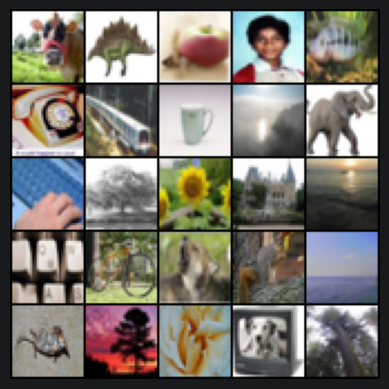

*******
ANALYZE DATASET


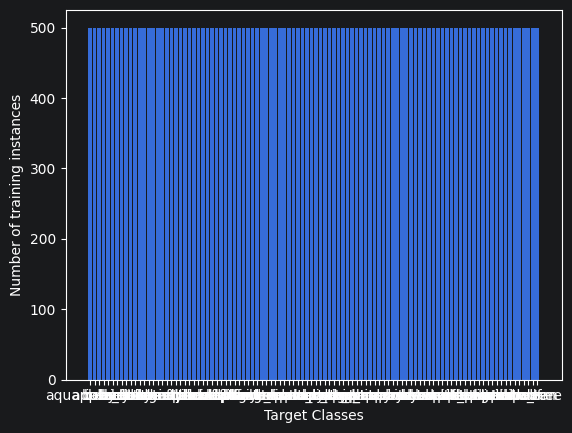

In [24]:
#prepare minibatches
batch_size = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

#visualization
print("******\nVISUALIZE DATA SET")
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()



#analyze dataset
print("*******\nANALYZE DATASET")
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

Build our model

In [25]:
class CNN(torch.nn.Module):
    def __init__(self,num_layers):
        super().__init__()
        layers = []
        in_channels = 3
        out_channels = 32
        for _ in range(num_layers):
            layers.append(torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                            kernel_size=3, padding=1))
            layers.append(torch.nn.ReLU())
            layers.append(torch.nn.MaxPool2d(kernel_size=2))
            in_channels = out_channels
            if out_channels < 64:
                out_channels += 16
            print(in_channels,out_channels)
        layers.append(torch.nn.Flatten())
        layers.append(torch.nn.Linear(in_channels * 4 * 4, 256))
        layers.append(torch.nn.ReLU())
        layers.append(torch.nn.Linear(256, 10))

        self.model = torch.nn.Sequential(
            *layers,
        )
    def forward(self,x):
        return self.model(x)

In [20]:
#gpu acceleration
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)

cuda


Train our model

In [23]:
num_epochs = 20
learning_rate = 0.001
weight_decay = 0.01
layers = 3
for i in range(layers):
    model = CNN(i).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay)


    #train
    print("\n\n*****************\nTRAINING STARTING\n****************")
    train_loss_list = []
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
        train_loss = 0
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss_list.append(train_loss / len(train_loader))
        print(f"Training loss = {train_loss_list[-1]}")
    print("\n\n*****************\nTRAINING DONE\n****************")
    plt.plot(range(1, num_epochs + 1), train_loss_list)
    plt.xlabel("Number of epochs")
    plt.ylabel("Training loss")
    plt.show()

    test_acc = 0
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            y_true = labels.to(device)
            outputs = model(images)
            _, y_pred = torch.max(outputs.data, 1)
            test_acc += (y_pred == y_true).sum().item()

    print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")
    num_images = 5
    y_true_name = [names[y_true[idx]] for idx in range(num_images)]
    y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
    title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

    plt.imshow(np.transpose(torchvision.utils.make_grid(
        images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()



*****************
TRAINING STARTING
****************
Epoch 1/20: 

RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x3072 and 16x256)

Test our model